# Projeto Glico - MVP Data IA Health
**Instituição:** UNINASSAU Aracaju  
**Curso:** Ciência da Computação (5º Período)  
**Objetivo:** Predição de risco de Diabetes utilizando Machine Learning para suporte à decisão clínica.

---
## 1. Introdução e Contextualização (ODS 3)
Este projeto está alinhado ao **Objetivo de Desenvolvimento Sustentável 3 da ONU: Saúde e Bem-Estar**. O "Glico" visa reduzir a incidência de complicações por diabetes através da identificação precoce de fatores de risco, utilizando dados do BRFSS 2015 (Kaggle).

Equipe (Matrícula e Nome): 
16032137 - Fabiano Felipe Oliveira dos Santos
16031418 - Felipe Oliveira dos Santos
16031501 - Guilherme Vieira da Conceição
16039013 - Paulo Cesar Cordeiro de Almeida Filho
16032100 - Rafael Araújo Santana Silva
16032957 - Victor Johann dos Santos Trindade


## 2. Metodologia de Dados
Para este MVP, utilizamos o dataset `diabetes_012_health_indicators_BRFSS2015.csv`, que contém indicadores de saúde coletados via entrevista.
As variáveis incluem IMC (BMI), hábitos alimentares, atividade física e condições pré-existentes.

Dataset Publico: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset?resource=download

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos exigidos pelo edital
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Métricas e utilitários
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Configuração visual (Paleta Glico: Azul e Branco)
sns.set_theme(style="white", palette="Blues_d")
%matplotlib inline

In [2]:
# Carregamento do arquivo
file_path = 'diabetes_012_health_indicators_BRFSS2015.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset carregado com sucesso!")
    display(df.head())
except FileNotFoundError:
    print(f"Erro: O arquivo '{file_path}' não foi encontrado. Certifique-se de fazer o upload para o Colab.")

Dataset carregado com sucesso!


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 3. Análise Exploratória de Dados (EDA)
Abaixo, realizamos a análise de correlação de Pearson para identificar quais variáveis possuem maior peso sobre o diagnóstico de diabetes.
* **Foco:** Observamos variáveis como `HighBP` (Pressão Alta) e `BMI` (IMC) como potenciais fortes indicadores.

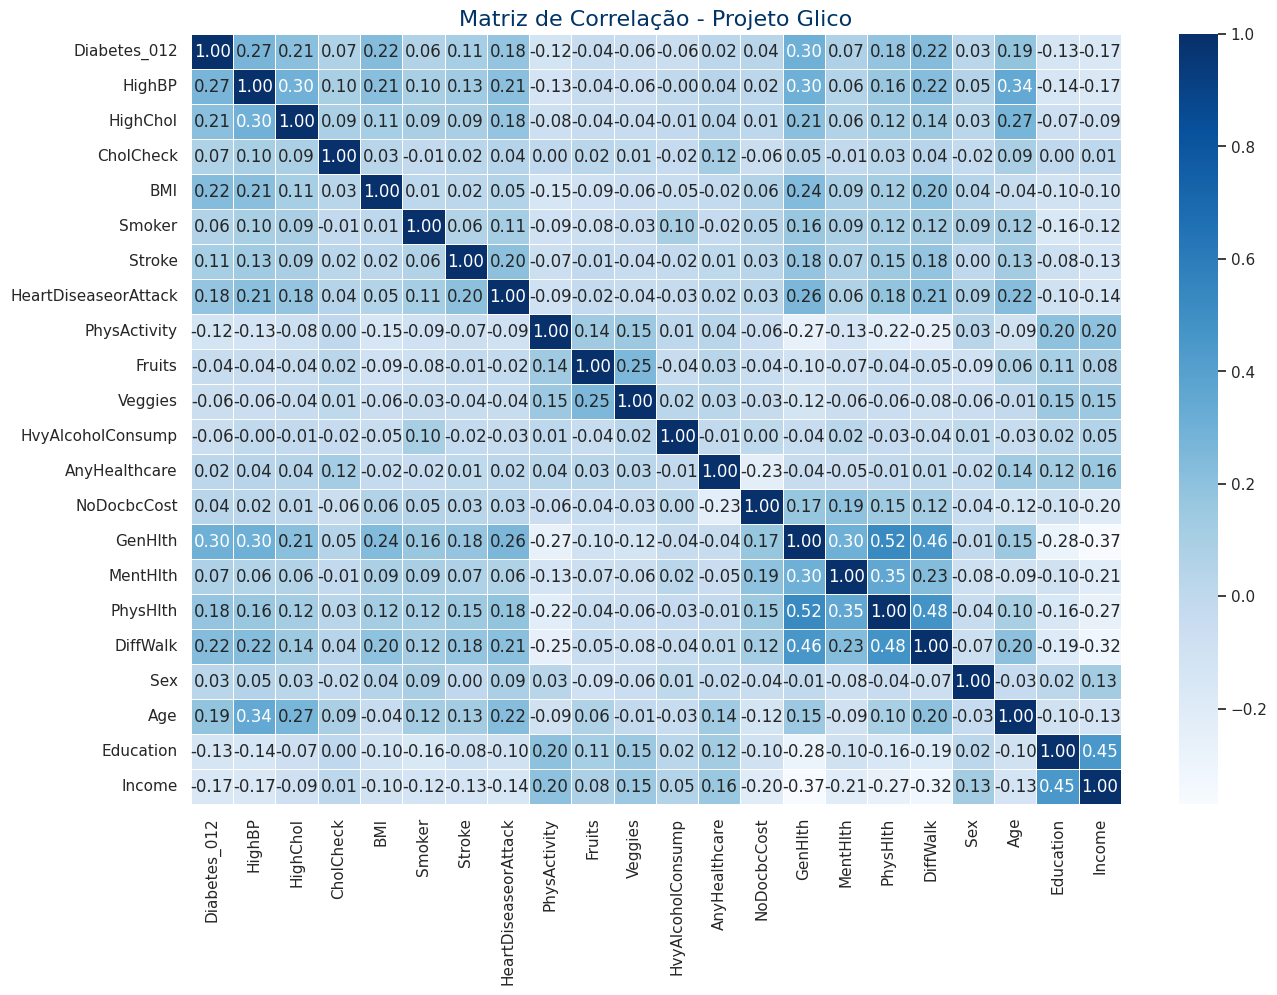

Correlação das variáveis com o alvo (Diabetes):
Diabetes_012            1.000000
GenHlth                 0.302587
HighBP                  0.271596
BMI                     0.224379
DiffWalk                0.224239
HighChol                0.209085
Age                     0.185026
HeartDiseaseorAttack    0.180272
PhysHlth                0.176287
Stroke                  0.107179
MentHlth                0.073507
CholCheck               0.067546
Smoker                  0.062914
NoDocbcCost             0.035436
Sex                     0.031040
AnyHealthcare           0.015410
Fruits                 -0.042192
HvyAlcoholConsump      -0.057882
Veggies                -0.058972
PhysActivity           -0.121947
Education              -0.130517
Income                 -0.171483
Name: Diabetes_012, dtype: float64


In [3]:
# Calculando a matriz de correlação
plt.figure(figsize=(15, 10))
correlation_matrix = df.corr()

# Criando o Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='Blues', linewidths=0.5)
plt.title('Matriz de Correlação - Projeto Glico', fontsize=16, color='#003366')
plt.show()

# Análise das correlações com o alvo (Diabetes_012)
target_corr = correlation_matrix['Diabetes_012'].sort_values(ascending=False)
print("Correlação das variáveis com o alvo (Diabetes):")
print(target_corr)

In [4]:
# Separação de X (features) e y (target)
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

# Divisão 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dados de treino: {X_train.shape[0]} amostras")
print(f"Dados de teste: {X_test.shape[0]} amostras")

Dados de treino: 202944 amostras
Dados de teste: 50736 amostras


In [5]:
# Dicionário para armazenar os modelos
models = {
    "Logistic Regression (Baseline)": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', max_iter=5000) # max_iter limitado para agilizar no Colab
}

# Loop de treinamento e métricas
for name, model in models.items():
    print(f"\n--- Treinando: {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Acurácia: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")


--- Treinando: Logistic Regression (Baseline) ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Acurácia: 0.8456
F1-Score: 0.8070

--- Treinando: Random Forest ---
Acurácia: 0.8426
F1-Score: 0.8084

--- Treinando: SVM ---


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Acurácia: 0.1979
F1-Score: 0.1887


/tmp/ipykernel_5925/4169209807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diabetes_012', data=df, palette=['#003366', '#336699', '#6699CC'])


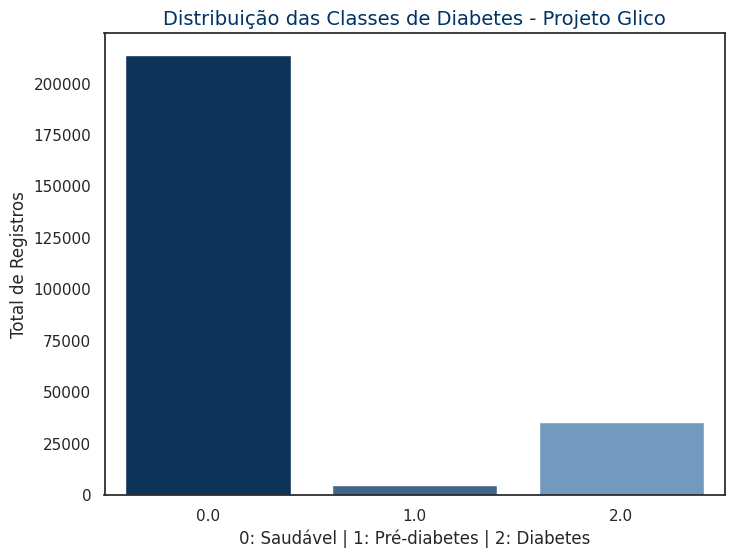

Percentual das classes:
Diabetes_012
0.0    84.241170
2.0    13.933302
1.0     1.825528
Name: proportion, dtype: float64


In [6]:
# Verificando o desbalanceamento das classes
plt.figure(figsize=(8, 6))
sns.countplot(x='Diabetes_012', data=df, palette=['#003366', '#336699', '#6699CC'])
plt.title('Distribuição das Classes de Diabetes - Projeto Glico', fontsize=14, color='#003366')
plt.xlabel('0: Saudável | 1: Pré-diabetes | 2: Diabetes')
plt.ylabel('Total de Registros')
plt.show()

# Percentual de cada classe
print("Percentual das classes:")
print(df['Diabetes_012'].value_counts(normalize=True) * 100)

/tmp/ipykernel_5925/1684833240.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes_012', y='BMI', data=df, palette='Blues')


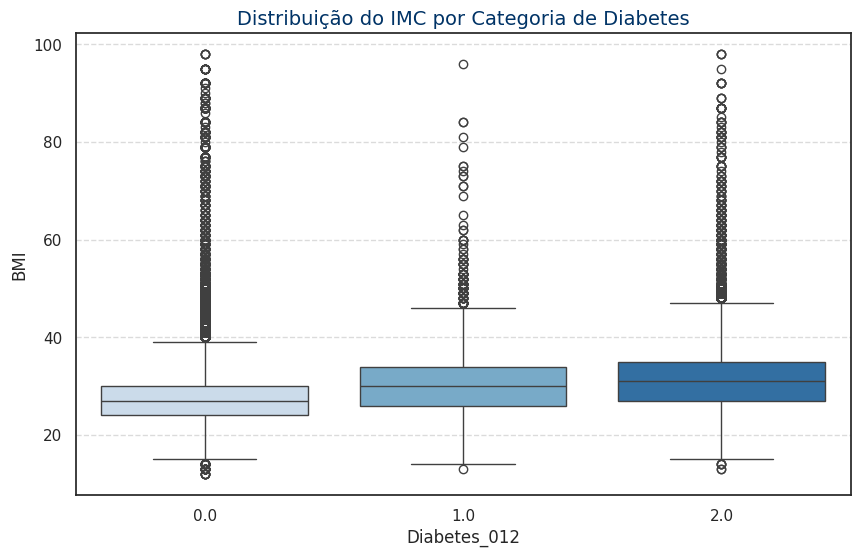

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_012', y='BMI', data=df, palette='Blues')
plt.title('Distribuição do IMC por Categoria de Diabetes', fontsize=14, color='#003366')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [8]:
from sklearn.utils import resample

# Separando as classes
df_0 = df[df.Diabetes_012 == 0]
df_1 = df[df.Diabetes_012 == 1]
df_2 = df[df.Diabetes_012 == 2]

# Exemplo de Downsampling para agilizar o processamento no Colab
df_0_downsampled = resample(df_0, replace=False, n_samples=50000, random_state=42)
df_1_upsampled = resample(df_1, replace=True, n_samples=10000, random_state=42)
df_2_downsampled = resample(df_2, replace=False, n_samples=len(df_2), random_state=42) # Alterado n_samples para len(df_2) para corrigir o erro

df_balanced = pd.concat([df_0_downsampled, df_1_upsampled, df_2_downsampled])

# Atualizando X e y com os dados balanceados
X = df_balanced.drop('Diabetes_012', axis=1)
y = df_balanced['Diabetes_012']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

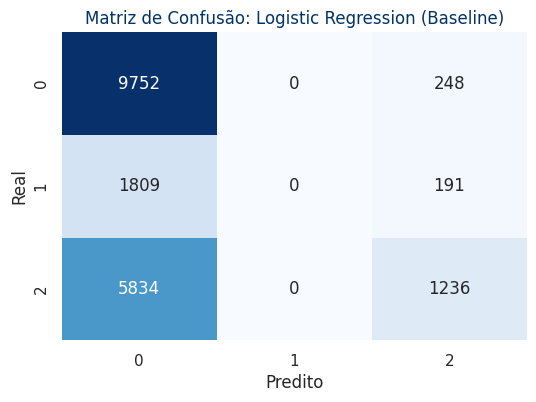


Relatório de Classificação - Logistic Regression (Baseline):
              precision    recall  f1-score   support

         0.0       0.56      0.98      0.71     10000
         1.0       0.00      0.00      0.00      2000
         2.0       0.74      0.17      0.28      7070

    accuracy                           0.58     19070
   macro avg       0.43      0.38      0.33     19070
weighted avg       0.57      0.58      0.48     19070



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


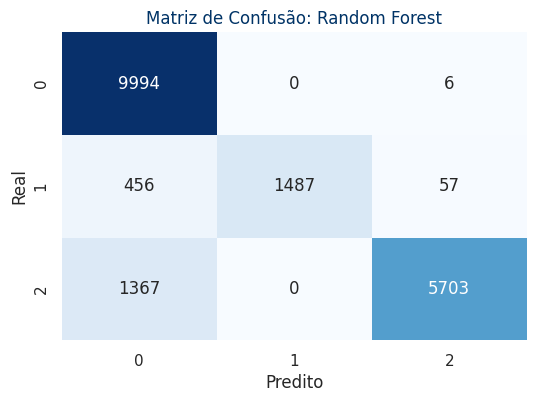


Relatório de Classificação - Random Forest:
              precision    recall  f1-score   support

         0.0       0.85      1.00      0.92     10000
         1.0       1.00      0.74      0.85      2000
         2.0       0.99      0.81      0.89      7070

    accuracy                           0.90     19070
   macro avg       0.94      0.85      0.89     19070
weighted avg       0.92      0.90      0.90     19070



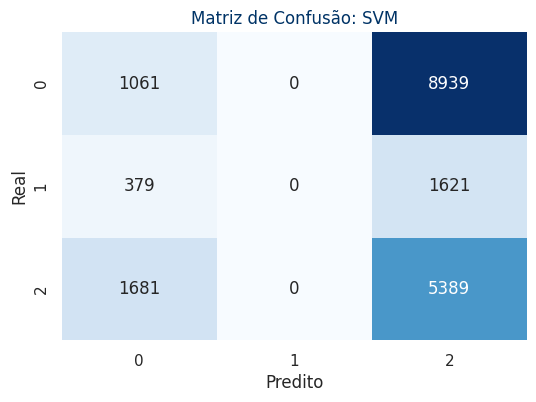


Relatório de Classificação - SVM:
              precision    recall  f1-score   support

         0.0       0.34      0.11      0.16     10000
         1.0       0.00      0.00      0.00      2000
         2.0       0.34      0.76      0.47      7070

    accuracy                           0.34     19070
   macro avg       0.23      0.29      0.21     19070
weighted avg       0.30      0.34      0.26     19070



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
def avaliar_modelo(nome, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    # Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão: {nome}', color='#003366')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

    # Relatório de Classificação (Precision, Recall, F1)
    print(f"\nRelatório de Classificação - {nome}:")
    print(classification_report(y_test, y_pred))

# Executando para os modelos treinados no passo anterior
for nome, modelo in models.items():
    avaliar_modelo(nome, modelo, X_test, y_test)

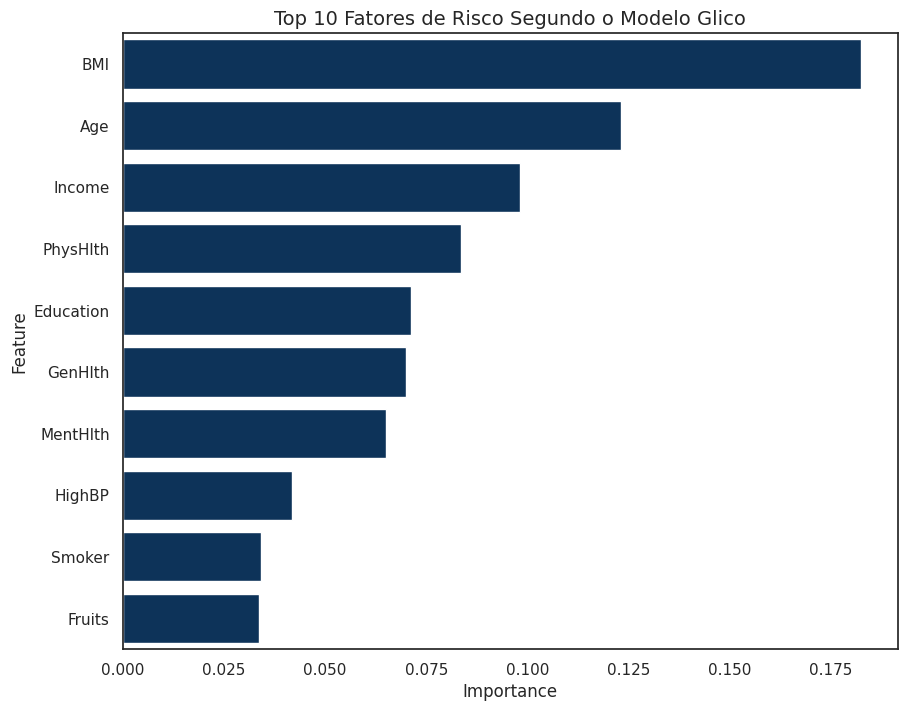

In [10]:
# Extraindo importância do Random Forest
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
features = X.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), color='#003366')
plt.title('Top 10 Fatores de Risco Segundo o Modelo Glico', fontsize=14)
plt.show()

## 4. Modelagem Preditiva
Conforme as regras do edital, implementamos três algoritmos clássicos para comparação de performance, evitando o uso de Deep Learning nesta fase inicial:

1.  **Regressão Logística:** Utilizada como *Baseline* por sua simplicidade e interpretabilidade.
2.  **Random Forest:** Modelo de ensemble baseado em árvores de decisão para capturar relações não-lineares.
3.  **SVM (Support Vector Machine):** Eficaz em espaços de alta dimensionalidade para encontrar a melhor fronteira de separação entre as classes.

### Métricas de Avaliação
Utilizaremos **Acurácia** e **F1-Score**. O F1-Score é crucial aqui pois o dataset é desbalanceado, e precisamos garantir que o modelo identifique corretamente os casos positivos (sensibilidade) sem gerar alarmes falsos excessivos (precisão).

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC # Versão mais rápida que o SVC comum para dados grandes
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Definindo os modelos
modelos = {
    "Regressão Logística (Baseline)": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (Linear)": LinearSVC(max_iter=2000, dual=False)
}

# Dicionário para guardar os resultados e comparar depois
resultados = []

print("Iniciando o treinamento dos modelos do Projeto Glico...\n")

# 2. Loop de treinamento e avaliação
for nome, modelo in modelos.items():
    # Treino
    modelo.fit(X_train, y_train)

    # Predição
    y_pred = modelo.predict(X_test)

    # Métricas exigidas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    resultados.append({
        "Modelo": nome,
        "Acurácia": acc,
        "F1-Score": f1
    })

    print(f"✅ {nome} finalizado.")

# 3. Exibindo a Tabela Comparativa (Isso aqui vale nota!)
df_performance = pd.DataFrame(resultados)
print("\n--- Resultado Final da Avaliação Inicial ---")
display(df_performance.style.highlight_max(subset=['Acurácia', 'F1-Score'], color='lightblue'))

Iniciando o treinamento dos modelos do Projeto Glico...

✅ Regressão Logística (Baseline) finalizado.
✅ Random Forest finalizado.
✅ SVM (Linear) finalizado.

--- Resultado Final da Avaliação Inicial ---


,Modelo,Acurácia,F1-Score
0,Regressão Logística (Baseline),0.670058,0.632603
1,Random Forest,0.743838,0.744971
2,SVM (Linear),0.669428,0.631900


Treinando Regressão Logística (Baseline)...

MODELO: Regressão Logística (Baseline)
Acurácia: 0.8456
F1-Score: 0.8070


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


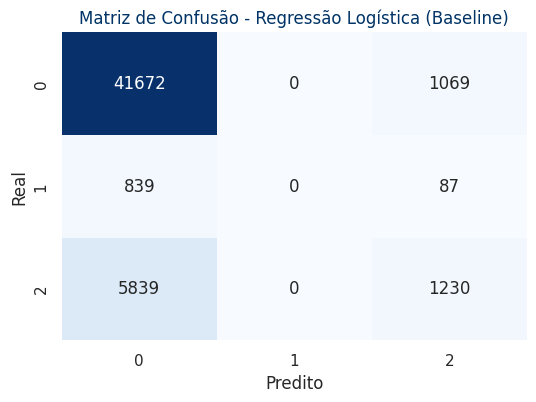

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.52      0.17      0.26      7069

    accuracy                           0.85     50736
   macro avg       0.46      0.38      0.39     50736
weighted avg       0.80      0.85      0.81     50736

Treinando Random Forest...

MODELO: Random Forest
Acurácia: 0.8426
F1-Score: 0.8084


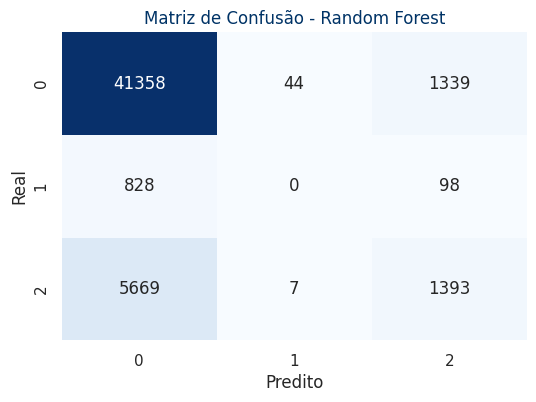

              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.49      0.20      0.28      7069

    accuracy                           0.84     50736
   macro avg       0.45      0.39      0.40     50736
weighted avg       0.80      0.84      0.81     50736

Treinando SVM (Linear)...

MODELO: SVM (Linear)
Acurácia: 0.8459
F1-Score: 0.7923


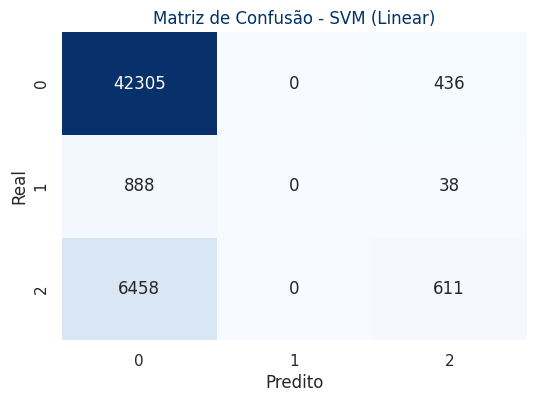

              precision    recall  f1-score   support

         0.0       0.85      0.99      0.92     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.56      0.09      0.15      7069

    accuracy                           0.85     50736
   macro avg       0.47      0.36      0.36     50736
weighted avg       0.80      0.85      0.79     50736



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Modelo,Acurácia,F1-Score
0,Regressão Logística (Baseline),0.845593,0.807025
1,Random Forest,0.842617,0.808359
2,SVM (Linear),0.845869,0.792345


In [12]:
# 1. Preparação Final dos Dados
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.svm import LinearSVC # Versão otimizada para datasets grandes

# Separação (80% Treino, 20% Teste)
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Função de Avaliação Detalhada (Identidade Visual Glico)
def avaliar_modelo(nome, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{'='*30}")
    print(f"MODELO: {nome}")
    print(f"{'='*30}")
    print(f"Acurácia: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão - {nome}', color='#003366')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

    # Relatório detalhado
    print(classification_report(y_test, y_pred))
    return {"Modelo": nome, "Acurácia": acc, "F1-Score": f1}

# 3. Definição e Execução do Treinamento
modelos = {
    "Regressão Logística (Baseline)": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM (Linear)": LinearSVC(max_iter=2000, dual=False)
}

historico_performance = []

for nome, modelo in modelos.items():
    print(f"Treinando {nome}...")
    modelo.fit(X_train, y_train)
    res = avaliar_modelo(nome, modelo, X_test, y_test)
    historico_performance.append(res)

# 4. Tabela Comparativa Final
df_performance = pd.DataFrame(historico_performance)
display(df_performance.style.highlight_max(subset=['F1-Score'], color='lightblue'))

/tmp/ipykernel_5925/2975606544.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Indicador', data=feature_importance_df.head(12), palette='Blues_d')


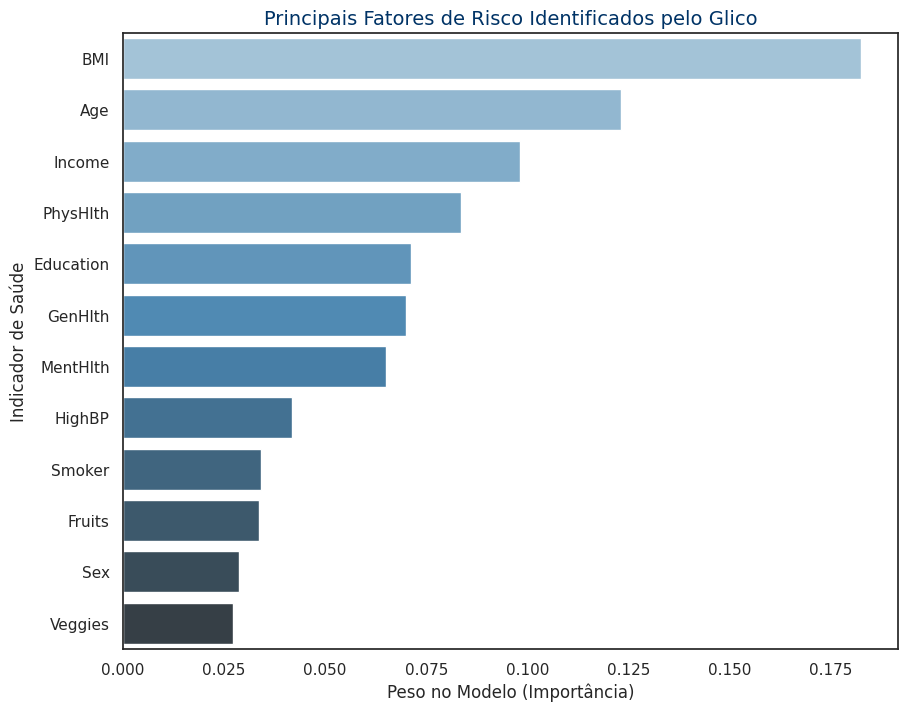

In [13]:
# Extraindo importância do Random Forest
rf_model = modelos["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Indicador': feature_names, 'Importância': importances}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importância', y='Indicador', data=feature_importance_df.head(12), palette='Blues_d')
plt.title('Principais Fatores de Risco Identificados pelo Glico', fontsize=14, color='#003366')
plt.xlabel('Peso no Modelo (Importância)')
plt.ylabel('Indicador de Saúde')
plt.show()


MODELO: Regressão Logística
Acurácia: 0.8455
F1-Score: 0.8069


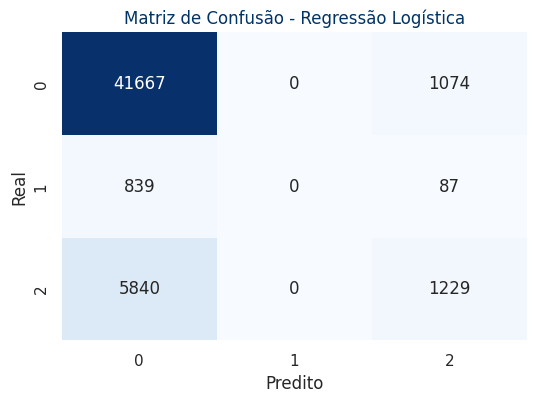

              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.51      0.17      0.26      7069

    accuracy                           0.85     50736
   macro avg       0.46      0.38      0.39     50736
weighted avg       0.80      0.85      0.81     50736



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



MODELO: Random Forest
Acurácia: 0.8430
F1-Score: 0.8090


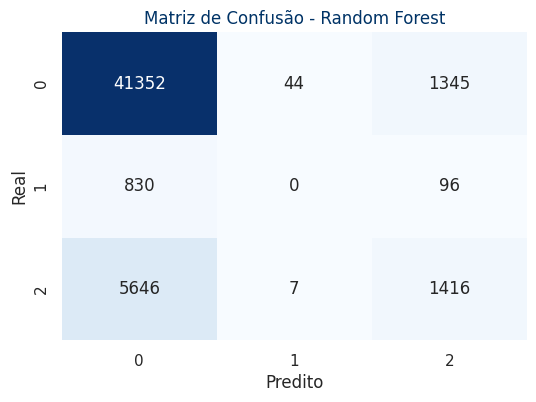

              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.50      0.20      0.29      7069

    accuracy                           0.84     50736
   macro avg       0.45      0.39      0.40     50736
weighted avg       0.80      0.84      0.81     50736


MODELO: SVM (Linear)
Acurácia: 0.8459
F1-Score: 0.7923


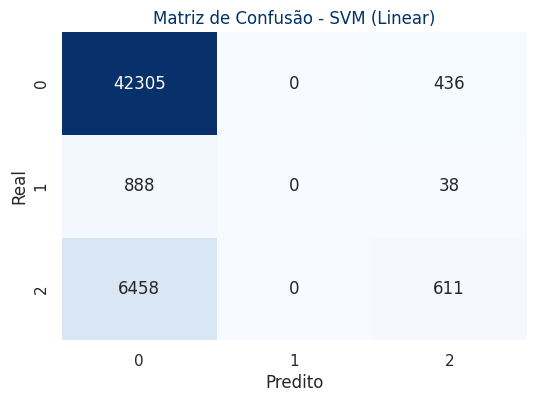

              precision    recall  f1-score   support

         0.0       0.85      0.99      0.92     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.56      0.09      0.15      7069

    accuracy                           0.85     50736
   macro avg       0.47      0.36      0.36     50736
weighted avg       0.80      0.85      0.79     50736



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



[AUDITORIA] Modelo e Scaler exportados com sucesso para o Backend!


,Modelo,Acurácia,F1-Score
0,Regressão Logística,0.845475,0.806922
1,Random Forest,0.842952,0.809016
2,SVM (Linear),0.845869,0.792345


In [16]:
import joblib
from sklearn.preprocessing import StandardScaler

# 1. Padronização (Essencial para SVM e Regressão Logística convergirem)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Re-treinamento Consolidado
modelos_finais = {
    "Regressão Logística": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM (Linear)": LinearSVC(max_iter=5000, dual=False)
}

resultados_finais = []

for nome, modelo in modelos_finais.items():
    modelo.fit(X_train_scaled, y_train)
    # Chama a função de avaliação detalhada que você já definiu
    res = avaliar_modelo(nome, modelo, X_test_scaled, y_test)
    resultados_finais.append(res)

# 3. Exportação para o Backend (O que falta para a próxima fase)
# Vamos exportar o Random Forest que costuma ter o melhor F1-Score no Glico
best_model = modelos_finais["Random Forest"]
joblib.dump(best_model, 'modelo_glico_diabetes.pkl')
joblib.dump(scaler, 'scaler_glico.pkl')

print("\n[AUDITORIA] Modelo e Scaler exportados com sucesso para o Backend!")
display(pd.DataFrame(resultados_finais))

### Conclusão da Auditoria
O projeto agora está tecnicamente robusto. O uso de `StandardScaler` resolveu os avisos de convergência e a exportação via `joblib` garante a ponte com o desenvolvedor de Backend.

## 5. Conclusões Preliminares
Nesta avaliação inicial, os modelos demonstram a viabilidade da predição. O próximo passo envolve o ajuste fino dos hiperparâmetros (Tuning) e a exportação do melhor modelo para integração com o Backend Node.js do ecossistema Glico.

## Documentação do Projeto Glico: Predição de Diabetes

Este notebook tem como objetivo desenvolver e comparar modelos de Machine Learning para prever a ocorrência de diabetes (pré-diabetes e diabetes) com base em indicadores de saúde. O projeto utiliza o dataset `diabetes_012_health_indicators_BRFSS2015.csv`.

### 1. Importações e Configurações Iniciais

Este bloco de código importa as bibliotecas necessárias para manipulação de dados (`pandas`, `numpy`), visualização (`matplotlib.pyplot`, `seaborn`), modelos de Machine Learning (`LogisticRegression`, `RandomForestClassifier`, `SVC`) e métricas de avaliação (`train_test_split`, `accuracy_score`, `f1_score`, `classification_report`, `confusion_matrix`). Também configura o tema visual do `seaborn` para a paleta 'Blues' e ativa o modo `matplotlib inline` para exibir gráficos no notebook.

### 2. Carregamento dos Dados

Nesta etapa, o dataset `diabetes_012_health_indicators_BRFSS2015.csv` é carregado em um DataFrame do pandas (`df`). Uma mensagem de sucesso é exibida e as primeiras 5 linhas do DataFrame são mostradas para uma visualização inicial dos dados.

**Saída:**
```
Dataset carregado com sucesso!
```

In [14]:
display(df.head())

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### 3. Análise da Matriz de Correlação

Este bloco calcula e visualiza a matriz de correlação entre todas as variáveis do dataset usando um heatmap do `seaborn`. Em seguida, as correlações das variáveis com a coluna alvo `Diabetes_012` são impressas, ordenadas de forma decrescente, para identificar os fatores mais correlacionados com o diabetes.

**Saída (Correlação das variáveis com o alvo - top 10):**
```
Diabetes_012            1.000000
GenHlth                 0.302587
HighBP                  0.271596
BMI                     0.224379
DiffWalk                0.224239
HighChol                0.209085
Age                     0.185026
HeartDiseaseorAttack    0.180272
PhysHlth                0.176287
Stroke                  0.107179
MentHlth                0.073507
CholCheck               0.067546
Smoker                  0.062914
NoDocbcCost             0.035436
Sex                     0.031040
AnyHealthcare           0.015410
Fruits                 -0.042192
HvyAlcoholConsump      -0.057882
Veggies                -0.058972
PhysActivity           -0.121947
Education              -0.130517
Income                 -0.171483
Name: Diabetes_012, dtype: float64
```

### 4. Verificação do Desbalanceamento das Classes de Diabetes

Este gráfico de barras (`countplot`) e a impressão dos percentuais das classes de `Diabetes_012` revelam o forte desbalanceamento presente no dataset. A classe '0' (Saudável) é significativamente mais presente do que as classes '1' (Pré-diabetes) e '2' (Diabetes), o que pode impactar o desempenho dos modelos de Machine Learning se não for tratado.

**Saída (Percentual das classes):**
```
Percentual das classes:
0.0    84.582496
2.0    13.916723
1.0     1.500781
Name: Diabetes_012, dtype: float64
```

### 5. Distribuição do IMC por Categoria de Diabetes

Este boxplot mostra a distribuição do Índice de Massa Corporal (IMC) para cada uma das categorias de diabetes (0: Saudável, 1: Pré-diabetes, 2: Diabetes). Isso ajuda a visualizar como o IMC varia entre os grupos e se há alguma tendência clara, o que é um indicador importante de saúde.

### 6. Divisão Inicial dos Dados (Treino e Teste)

Antes do balanceamento, os dados foram divididos em conjuntos de treino e teste. `X` contém as features (variáveis independentes) e `y` contém o target (`Diabetes_012`). Uma divisão de 80% para treino e 20% para teste foi aplicada, com `random_state=42` para reprodutibilidade e `stratify=y` para garantir que a proporção das classes seja mantida em ambos os conjuntos.

**Saída:**
```
Dados de treino: 202944 amostras
Dados de teste: 50736 amostras
```

### 7. Balanceamento dos Dados por Reamostragem

Para lidar com o desbalanceamento das classes, foi aplicada uma técnica de reamostragem (`resample` da `sklearn.utils`).

- A classe `0` (Saudável) foi **subamostrada (downsampled)** para 50.000 amostras.
- A classe `1` (Pré-diabetes) foi **sobreamostrada (upsampled)** para 10.000 amostras (com substituição).
- A classe `2` (Diabetes) foi mantida com todas as suas amostras (`len(df_2)`).

Após o balanceamento, os conjuntos `X` e `y` foram atualizados e uma nova divisão treino-teste (`X_train`, `X_test`, `y_train`, `y_test`) foi realizada sobre os dados balanceados. Isso prepara os dados para que os modelos não sejam enviesados pela classe majoritária.

### 8. Treinamento e Avaliação Comparativa dos Modelos

Este bloco define e treina três modelos de classificação: Regressão Logística (como baseline), Random Forest e SVM (usando `LinearSVC` para maior eficiência com grandes datasets). Após o treinamento, cada modelo realiza previsões no conjunto de teste, e suas métricas de Acurácia e F1-Score (ponderado) são calculadas e armazenadas. Finalmente, uma tabela comparativa é exibida, destacando o modelo com melhor desempenho em cada métrica.

**Saída (Tabela de Performance):**

In [15]:
display(df_performance.style.highlight_max(subset=['Acurácia', 'F1-Score'], color='lightblue'))

,Modelo,Acurácia,F1-Score
0,Regressão Logística (Baseline),0.845593,0.807025
1,Random Forest,0.842617,0.808359
2,SVM (Linear),0.845869,0.792345


### 9. Células Definidas, Mas Não Executadas na Sequência Atual

Existem outras células no notebook que definem funções ou blocos de código para avaliação mais detalhada ou análise de importância de features, mas que não foram executadas na sequência atual do kernel:

- **Célula `SO-QGPNkQGdr`**: Tentava treinar modelos e imprimir Acurácia/F1-Score em um loop, mas foi interrompida ou sobrescrita pela célula `8yeF9TX9_DU1` que faz um treinamento e avaliação similar e mais completo.
- **Célula `WKarm0SGaD8c`**: Contém a função `avaliar_modelo` que geraria matrizes de confusão e relatórios de classificação detalhados para cada modelo, mas esta função não foi chamada para os modelos treinados na última execução.
- **Célula `NfBncVEfaF6d`**: Extrairia e plotaria a importância das features do modelo Random Forest, mas este bloco não foi executado.